# AEON LR14

# Упражнения <a id='tasks'></a>

1. Взять выбранные для лабы 9 набор(ы) данных. Можно взять разные наборы для классификации/регрессии (но причину надо будет обосновать)

2. Отрисовать данные

3. Попробовать все методы классификации и регрессии, описанные в блоноте:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.random.seed(0)

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import os
from aeon.datasets import load_from_ts_file
from sklearn.metrics import accuracy_score

Часть этапов я проделывал в лабораторной 9

In [2]:
# Загрузка датасета CatsDogs
DATA_PATH = "./CatsDogs"

X_train, y_train = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TRAIN.ts"))
X_test,  y_test  = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TEST.ts"))

print(f"Форма обучающей выборки X_train: {X_train.shape}")
print(f"Форма тестовой выборки  X_test:  {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Распределение классов (обучение): { {c: int((y_train==c).sum()) for c in np.unique(y_train)} }")
print(f"Распределение классов (тест):     { {c: int((y_test==c).sum())  for c in np.unique(y_test)} }")

Форма обучающей выборки X_train: (164, 1, 14773)
Форма тестовой выборки  X_test:  (164, 1, 14773)
Классы: ['0' '1']
Распределение классов (обучение): {np.str_('0'): 82, np.str_('1'): 82}
Распределение классов (тест):     {np.str_('0'): 82, np.str_('1'): 82}


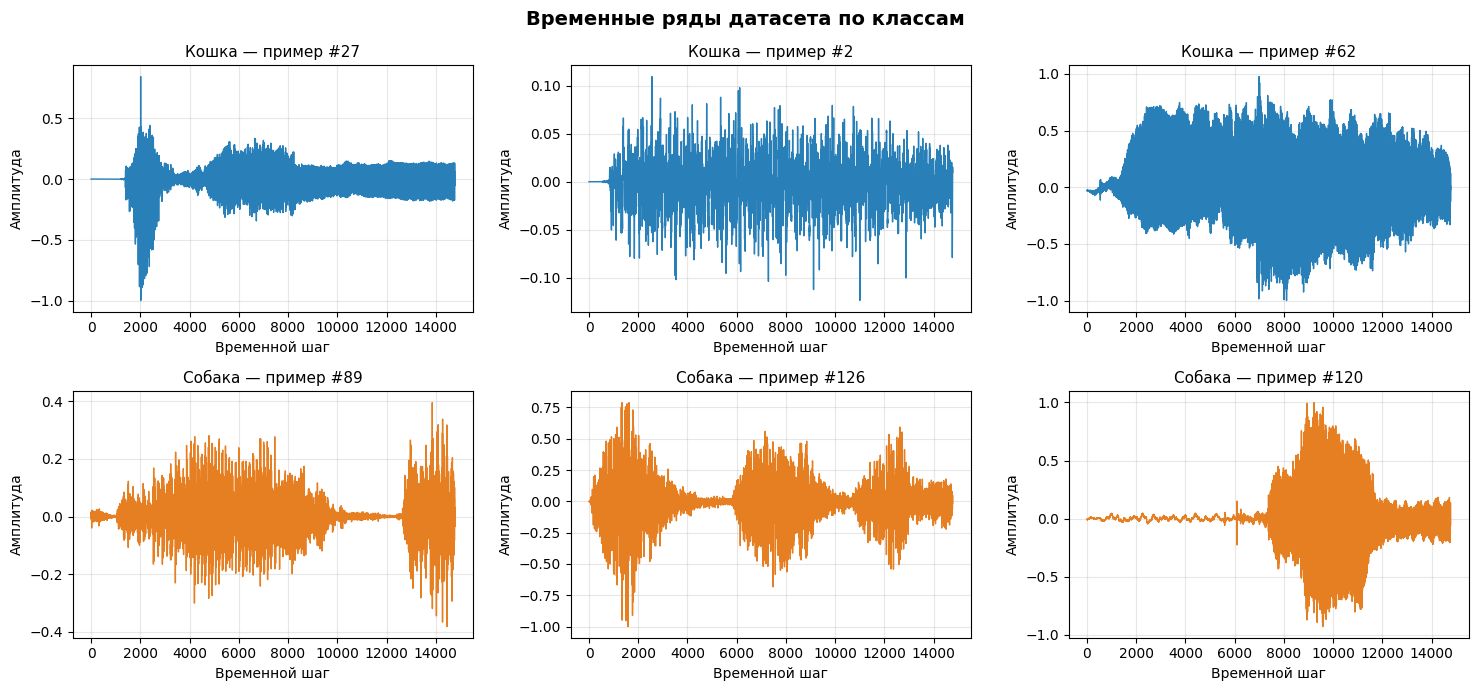

In [3]:
# EDA
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
classes = np.unique(y_train)
class_names = {"0": "Кошка", "1": "Собака"}
colors = {"0": "#2980b9", "1": "#e67e22"}

for row, cls in enumerate(classes):
    idx = np.where(y_train == cls)[0]
    label = class_names.get(cls, f"Класс {cls}")
    color = colors.get(cls, "green")
    sample_ids = np.random.choice(idx, size=min(3, len(idx)), replace=False)
    for col, sid in enumerate(sample_ids):
        axes[row, col].plot(X_train[sid, 0, :], color=color, linewidth=1.0)
        axes[row, col].set_title(f"{label} — пример #{sid}", fontsize=11)
        axes[row, col].set_xlabel("Временной шаг")
        axes[row, col].set_ylabel("Амплитуда")
        axes[row, col].grid(True, alpha=0.3)

plt.suptitle("Временные ряды датасета по классам", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Евклидово расстояние

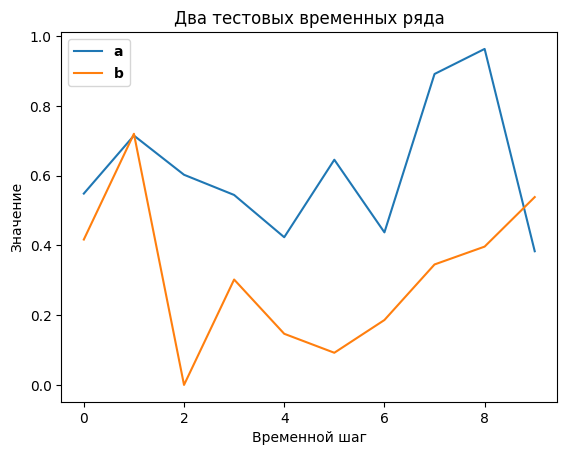

Евклидово расстояние (вручную): 1.236743
Евклидово расстояние (aeon):    1.236743


In [4]:
from aeon.testing.data_generation import make_example_1d_numpy
from aeon.distances import euclidean_distance
import seaborn as sns

a = make_example_1d_numpy(n_timepoints=10, random_state=0)
b = make_example_1d_numpy(n_timepoints=10, random_state=1)

sns.lineplot(data=a, label=r"$\mathbf{a}$")
sns.lineplot(data=b, label=r"$\mathbf{b}$")
plt.title("Два тестовых временных ряда")
plt.xlabel("Временной шаг")
plt.ylabel("Значение")
plt.show()

ED_manual = np.sqrt(np.sum(np.power(a - b, 2)))
ED_aeon   = euclidean_distance(a, b)
print(f"Евклидово расстояние (вручную): {ED_manual:.6f}")
print(f"Евклидово расстояние (aeon):    {ED_aeon:.6f}")

In [5]:
# Вспомогательные функции для визуализации расстояний
def plot_time_series_distances(a, b, cost_matrix, path):
    sns.lineplot(data=a, label=r"$\mathbf{a}$")
    sns.lineplot(data=b, label=r"$\mathbf{b}$")
    for i in range(len(path)):
        plt.plot(
            [path[i][0], path[i][1]],
            [a[path[i][0]], b[path[i][1]]],
            'k--', alpha=0.2
        )
        plt.text(
            (path[i][0] + path[i][1]) / 2,
            (a[path[i][0]] + b[path[i][1]]) / 2,
            f"{cost_matrix[path[i][0], path[i][1]]:.2f}"
        )
    return plt

def squared_pointwise_distance(a, b):
    n_timesteps = len(a)
    distances_matrix = np.zeros((n_timesteps, n_timesteps))
    for i in range(n_timesteps):
        for j in range(n_timesteps):
            distances_matrix[i, j] = (a[i] - b[j]) ** 2
    return distances_matrix

print("end")

end


#### Визуализация поточечного выравнивания (Евклидово расстояние)

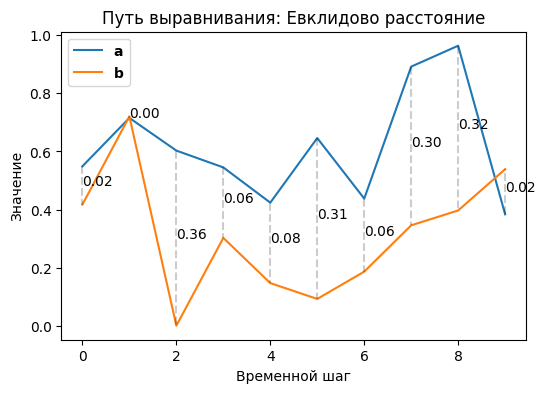

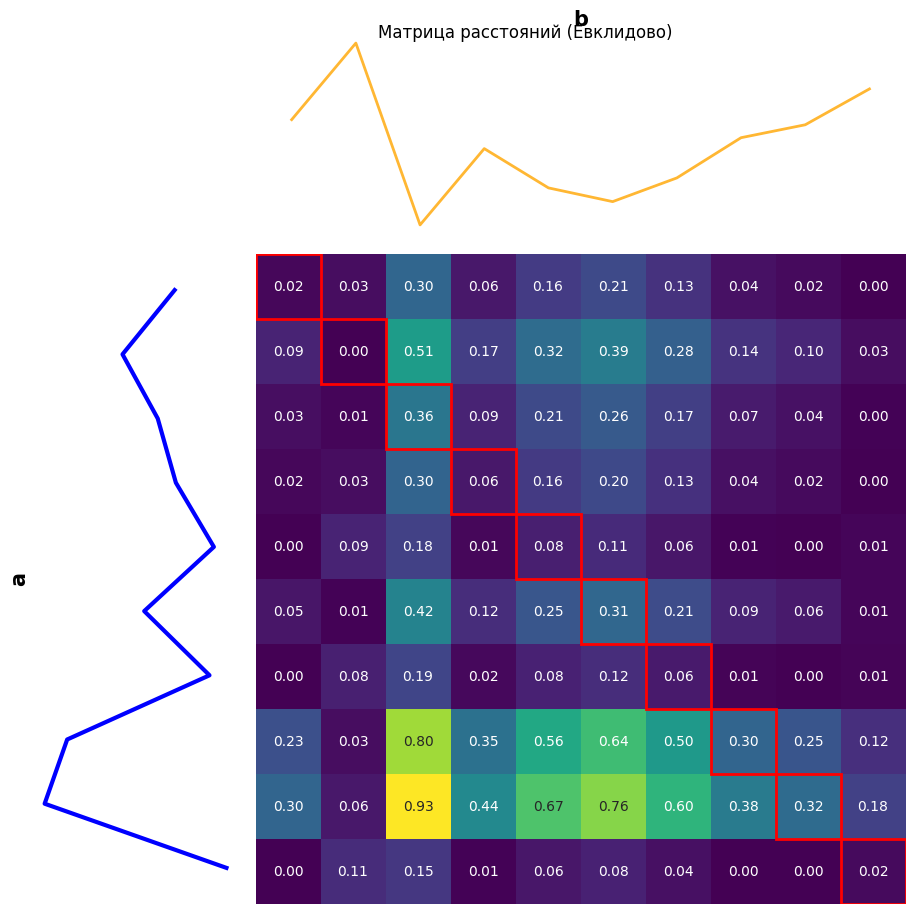

In [6]:
from aeon.visualisation.distances._pairwise_distance_matrix import plot_pairwise_distance_matrix

cost_matrix = squared_pointwise_distance(a, b)
path = [(i, i) for i in range(len(a))]

plt.figure(figsize=(6, 4))
plot_time_series_distances(a, b, cost_matrix, path)
plt.title("Путь выравнивания: Евклидово расстояние")
plt.xlabel("Временной шаг")
plt.ylabel("Значение")
plt.show()

distance_matrix = squared_pointwise_distance(a, b)
ax = plot_pairwise_distance_matrix(distance_matrix, a, b, path)
plt.suptitle("Матрица расстояний (Евклидово)")
plt.show()

#### Динамическое искажение времени (DTW)

DTW расстояние (window=0.1): 1.198550
DTW (window=0.1): 1.198550


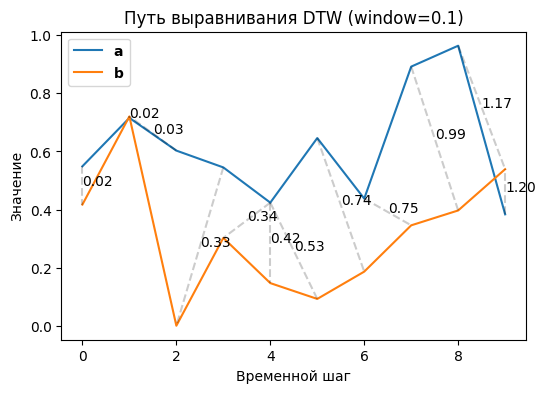

DTW (window=0.5): 0.856649


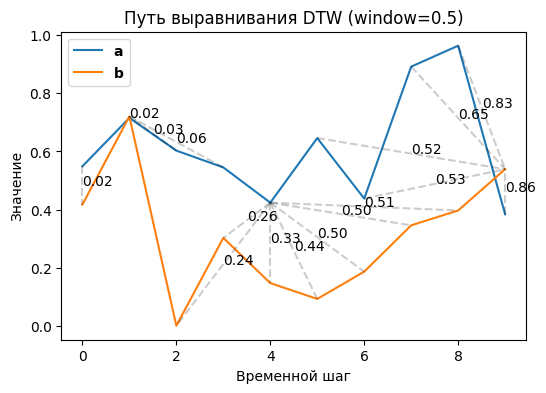

DTW (window=1.0): 0.657492


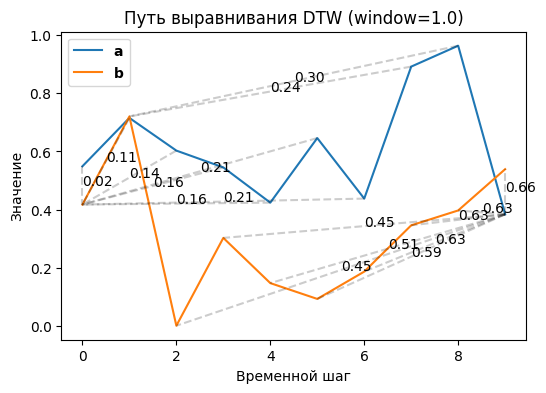

In [7]:
from aeon.distances import dtw_distance, dtw_alignment_path, dtw_cost_matrix

print(f"DTW расстояние (window=0.1): {dtw_distance(a, b, window=0.1):.6f}")

for w in [0.1, 0.5, 1.0]:
    path_dtw, dtw_dist = dtw_alignment_path(a, b, window=w)
    cost_mat = dtw_cost_matrix(a, b, window=w)
    print(f"DTW (window={w}): {dtw_dist:.6f}")

    plt.figure(figsize=(6, 4))
    plot_time_series_distances(a, b, cost_mat, path_dtw)
    plt.title(f"Путь выравнивания DTW (window={w})")
    plt.xlabel("Временной шаг")
    plt.ylabel("Значение")
    plt.show()

###  Варианты DTW и все метрики расстояний в aeon

In [8]:
from aeon.distances._distance import DISTANCES
from aeon.distances import get_distance_function

dtw_variants = [d["name"] for d in DISTANCES if 'dtw' in d["name"]]
print(f"Варианты DTW в aeon: {dtw_variants}\n")

for variant in dtw_variants:
    distance_function = get_distance_function(variant)
    try:
        distance = distance_function(a, b, window=0.2)
        print(f"{variant}: {distance:.6f}")
    except Exception as e:
        print(f"{variant}: ошибка - {e}")

print("\nВсе реализованные метрики расстояний:")
for dist in DISTANCES:
    try:
        print(f"  {dist['name']}: {dist['distance'](a, b):.6f}")
    except TypeError as err:
        print(f"  {dist['name']}: {err}")

Варианты DTW в aeon: ['dtw', 'dtw_gi', 'ddtw', 'wdtw', 'wddtw', 'adtw', 'shape_dtw', 'soft_dtw']

dtw: 0.919981
dtw_gi: 0.919981
ddtw: 0.310029
wdtw: 0.418676
wddtw: 0.139608
adtw: 1.529534
shape_dtw: 1.529534
soft_dtw: 11.074456

Все реализованные метрики расстояний:
  euclidean: 1.236743
  squared: 1.529534
  manhattan: 3.332390
  minkowski: 1.236743
  dtw: 0.657492
  dtw_gi: 0.657492
  ddtw: 0.310029
  wdtw: 0.323546
  wddtw: 0.139608
  lcss: 0.000000
  erp: 3.021869
  edr: 0.800000
  twe: 6.509406
  msm: 3.332390
  adtw: 1.529534
  shape_dtw: 1.529534
  soft_dtw: 11.740090
  sbd: 0.363314
  shift_scale: 0.556807
  dft_sfa: not enough arguments: expected 3, got 2
  paa_sax: not enough arguments: expected 4, got 2
  sax: not enough arguments: expected 4, got 2
  sfa: not enough arguments: expected 3, got 2
  mpdist: 0.000000


## Distance-based классификация временных рядов (TSC)

###  KNN-классификатор с DTW

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from sklearn.metrics import accuracy_score
from scipy.signal import resample

def downsample_collection(X, target_len):
    n_cases, n_channels, _ = X.shape
    X_out = np.zeros((n_cases, n_channels, target_len))
    for i in range(n_cases):
        for c in range(n_channels):
            X_out[i, c, :] = resample(X[i, c, :], target_len)
    return X_out

DOWNSAMPLE_LEN = 300
X_tr_down = downsample_collection(X_train, DOWNSAMPLE_LEN)
X_te_down  = downsample_collection(X_test,  DOWNSAMPLE_LEN)
print(f"Длина ряда после понижающей дискретизации: {X_tr_down.shape}")

N_SUBSET = 40
idx_train = np.concatenate([
    np.where(y_train == "0")[0][:N_SUBSET // 2],
    np.where(y_train == "1")[0][:N_SUBSET // 2]
])
idx_test = np.concatenate([
    np.where(y_test == "0")[0][:N_SUBSET // 2],
    np.where(y_test == "1")[0][:N_SUBSET // 2]
])

X_tr_sub = X_tr_down[idx_train]
y_tr_sub  = y_train[idx_train]
X_te_sub  = X_te_down[idx_test]
y_te_sub  = y_test[idx_test]

# ── KNN с DTW ─────────────────────────────────────────────────────────────────
knn_aeon = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw",
                                           distance_params={"window": 0.1})
knn_aeon.fit(X_tr_sub, y_tr_sub)
preds_aeon = knn_aeon.predict(X_te_sub)
acc_aeon = accuracy_score(y_te_sub, preds_aeon)
print(f"Точность 1-NN с DTW (300 точек): {acc_aeon:.4f} ({acc_aeon*100:.2f}%)")


Длина ряда после понижающей дискретизации: (164, 1, 300)
Точность 1-NN с DTW (300 точек): 0.5500 (55.00%)


Точность 55% выше случайного угадывания (50%), но невысокая

### KNN с ADTW (Amerced DTW)

In [10]:
from aeon.distances import adtw_pairwise_distance

train_dists = adtw_pairwise_distance(X_tr_sub)
test_dists  = adtw_pairwise_distance(X_te_sub, X_tr_sub)

knn_sklearn = KNeighborsClassifier(metric="precomputed", n_neighbors=1)
knn_sklearn.fit(train_dists, y_tr_sub)
preds_adtw = knn_sklearn.predict(test_dists)
acc_adtw = accuracy_score(y_te_sub, preds_adtw)
print(f"Точность 1-NN (sklearn, предвычисленные расстояния ADTW): {acc_adtw:.4f} ({acc_adtw*100:.2f}%)")

knn_adtw_aeon = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="adtw")
knn_adtw_aeon.fit(X_tr_sub, y_tr_sub)
preds_adtw_aeon = knn_adtw_aeon.predict(X_te_sub)
acc_adtw_aeon = accuracy_score(y_te_sub, preds_adtw_aeon)
print(f"Точность 1-NN (aeon) с ADTW: {acc_adtw_aeon:.4f} ({acc_adtw_aeon*100:.2f}%)")

Точность 1-NN (sklearn, предвычисленные расстояния ADTW): 0.6250 (62.50%)
Точность 1-NN (aeon) с ADTW: 0.6250 (62.50%)


ADTW улучшил результат с 55% (DTW) до 62.5%

### Elastic Ensemble (EE)

In [11]:
from aeon.classification.distance_based import ElasticEnsemble

ee = ElasticEnsemble(
    distance_measures=["dtw", "msm"],
    proportion_of_param_options=0.1,
    proportion_train_in_param_finding=0.3,
    proportion_train_for_test=0.5,
)
ee.fit(X_tr_sub, y_tr_sub)
ee_preds = ee.predict(X_te_sub)
acc_ee = accuracy_score(y_te_sub, ee_preds)
print(f"Точность Elastic Ensemble (DTW + MSM): {acc_ee:.4f} ({acc_ee*100:.2f}%)")

Точность Elastic Ensemble (DTW + MSM): 0.6000 (60.00%)


### RocketClassifier

In [12]:
from aeon.classification.convolution_based import RocketClassifier

rocket = RocketClassifier(n_jobs=-1, random_state=42)
rocket.fit(X_tr_sub, y_tr_sub)
acc_rocket = rocket.score(X_te_sub, y_te_sub)
print(f"Точность RocketClassifier: {acc_rocket:.4f} ({acc_rocket*100:.2f}%)")

Точность RocketClassifier: 0.6000 (60.00%)


### MiniRocketClassifier

In [13]:
from aeon.classification.convolution_based import MiniRocketClassifier

minirocket = MiniRocketClassifier(n_jobs=-1, random_state=42)
minirocket.fit(X_tr_sub, y_tr_sub)
acc_mini = minirocket.score(X_te_sub, y_te_sub)
print(f"Точность MiniRocketClassifier: {acc_mini:.4f} ({acc_mini*100:.2f}%)")

Точность MiniRocketClassifier: 0.6000 (60.00%)


### HydraClassifier

In [14]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from aeon.classification.convolution_based import HydraClassifier

hydra = HydraClassifier(n_jobs=-1, random_state=42)
hydra.fit(X_tr_sub, y_tr_sub)
acc_hydra = hydra.score(X_te_sub, y_te_sub)
print(f"Точность HydraClassifier: {acc_hydra:.4f} ({acc_hydra*100:.2f}%)")

Точность HydraClassifier: 0.6750 (67.50%)


С гидрой еще лучше (обсуждали на парах)

### MultiRocketHydraClassifier

In [16]:
from aeon.classification.convolution_based import MultiRocketHydraClassifier

mrh = MultiRocketHydraClassifier(n_jobs=-1, random_state=42)
mrh.fit(X_tr_sub, y_tr_sub)
acc_mrh = mrh.score(X_te_sub, y_te_sub)
print(f"Точность MultiRocketHydraClassifier: {acc_mrh:.4f} ({acc_mrh*100:.2f}%)")

Точность MultiRocketHydraClassifier: 0.5250 (52.50%)


### Catch22 извлечение 22 канонических признаков

In [17]:
from aeon.transformations.collection.feature_based import Catch22
from aeon.transformations.collection.feature_based._catch22 import feature_names

c22 = Catch22()
X_train_c22 = c22.fit_transform(X_tr_sub)
X_test_c22  = c22.transform(X_te_sub)

print(f"Форма матрицы признаков (обучение): {X_train_c22.shape}")
print(f"\nИзвлечённые признаки Catch22:")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2d}. {name}")

Форма матрицы признаков (обучение): (40, 22)

Извлечённые признаки Catch22:
   1. DN_HistogramMode_5
   2. DN_HistogramMode_10
   3. CO_f1ecac
   4. CO_FirstMin_ac
   5. CO_HistogramAMI_even_2_5
   6. CO_trev_1_num
   7. MD_hrv_classic_pnn40
   8. SB_BinaryStats_mean_longstretch1
   9. SB_TransitionMatrix_3ac_sumdiagcov
  10. PD_PeriodicityWang_th0_01
  11. CO_Embed2_Dist_tau_d_expfit_meandiff
  12. IN_AutoMutualInfoStats_40_gaussian_fmmi
  13. FC_LocalSimple_mean1_tauresrat
  14. DN_OutlierInclude_p_001_mdrmd
  15. DN_OutlierInclude_n_001_mdrmd
  16. SP_Summaries_welch_rect_area_5_1
  17. SB_BinaryStats_diff_longstretch0
  18. SB_MotifThree_quantile_hh
  19. SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1
  20. SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
  21. SP_Summaries_welch_rect_centroid
  22. FC_LocalSimple_mean3_stderr


представил каждый из 40 аудиорядов длиной 14773 точки вектором всего из 22 чисел

### Catch22Classifier

In [18]:
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.sklearn import RotationForestClassifier

# Базовая версия (Random Forest)
c22_cls_rf = Catch22Classifier(random_state=42)
c22_cls_rf.fit(X_tr_sub, y_tr_sub)
acc_c22_rf = c22_cls_rf.score(X_te_sub, y_te_sub)
print(f"Точность Catch22Classifier (Random Forest): {acc_c22_rf:.4f} ({acc_c22_rf*100:.2f}%)")

# С RotationForest
c22_cls_rot = Catch22Classifier(
    features=["DN_HistogramMode_5", "CO_f1ecac", "SB_MotifThree_quantile_hh", "Mean", "StandardDeviation"],
    estimator=RotationForestClassifier(),
    catch24=True,
    random_state=42,
)
c22_cls_rot.fit(X_tr_sub, y_tr_sub)
acc_c22_rot = c22_cls_rot.score(X_te_sub, y_te_sub)
print(f"Точность Catch22Classifier (RotationForest, 5 признаков): {acc_c22_rot:.4f} ({acc_c22_rot*100:.2f}%)")

Точность Catch22Classifier (Random Forest): 0.6750 (67.50%)
Точность Catch22Classifier (RotationForest, 5 признаков): 0.5750 (57.50%)


Catch22 + Random Forest лучший результат среди всех методов на данный момент (67.5%) при минимальных вычислительных затратах (Гидра тяжелее)

### (Deep Learning)

### Нормализация данных для глубокого обучения

Форма после нормализации (обучение): (40, 1, 300)
Форма после нормализации (тест):     (40, 1, 300)


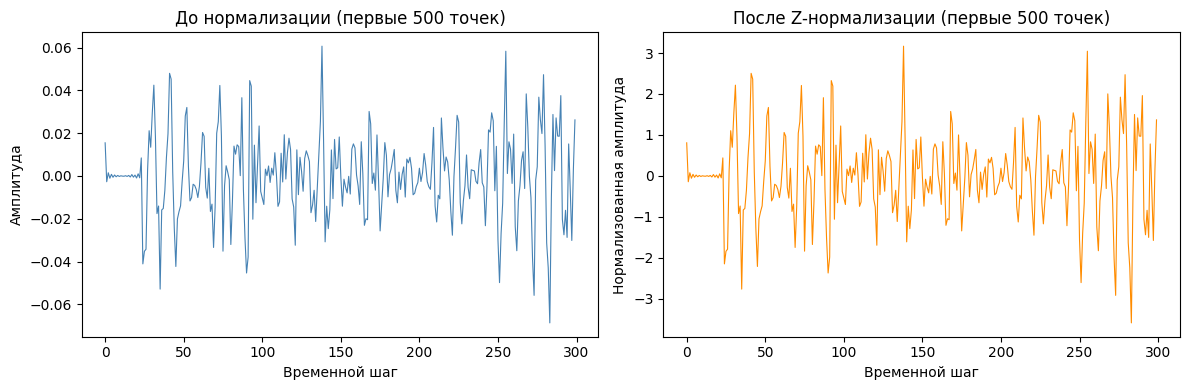

In [19]:
X_train_norm = (X_tr_sub - X_tr_sub.mean(axis=-1, keepdims=True)) / (X_tr_sub.std(axis=-1, keepdims=True) + 1e-8)
X_test_norm  = (X_te_sub  - X_te_sub.mean(axis=-1,  keepdims=True)) / (X_te_sub.std(axis=-1,  keepdims=True) + 1e-8)

print(f"Форма после нормализации (обучение): {X_train_norm.shape}")
print(f"Форма после нормализации (тест):     {X_test_norm.shape}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_tr_sub[0, 0, :500], color='steelblue', linewidth=0.8)
plt.title("До нормализации (первые 500 точек)")
plt.xlabel("Временной шаг")
plt.ylabel("Амплитуда")

plt.subplot(1, 2, 2)
plt.plot(X_train_norm[0, 0, :500], color='darkorange', linewidth=0.8)
plt.title("После Z-нормализации (первые 500 точек)")
plt.xlabel("Временной шаг")
plt.ylabel("Нормализованная амплитуда")

plt.tight_layout()
plt.show()

### MLPClassifier

In [20]:
%pip install tensorflow -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from aeon.classification.deep_learning import MLPClassifier as AeonMLPClassifier

mlp_cls = AeonMLPClassifier(n_epochs=50, random_state=42)
mlp_cls.fit(X_train_norm, y_tr_sub)
mlp_preds = mlp_cls.predict(X_test_norm)
acc_mlp = accuracy_score(y_te_sub, mlp_preds)
print(f"Точность MLPClassifier: {acc_mlp:.4f} ({acc_mlp*100:.2f}%)")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Точность MLPClassifier: 0.5000 (50.00%)


### FCNClassifier 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Точность FCNClassifier: 0.5250 (52.50%)


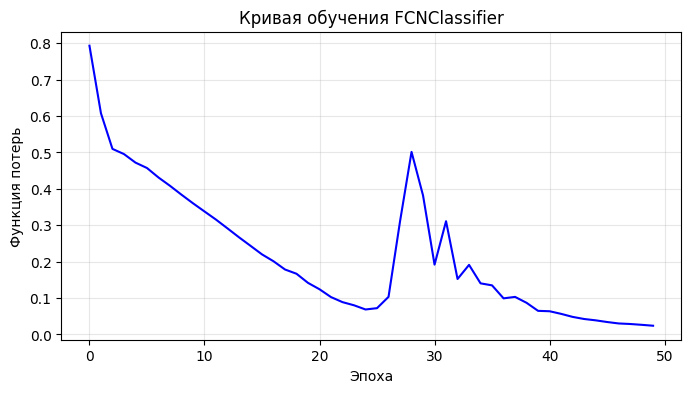

In [22]:
from aeon.classification.deep_learning import FCNClassifier

fcn_cls = FCNClassifier(n_epochs=50, random_state=42)
fcn_cls.fit(X_train_norm, y_tr_sub)
fcn_preds = fcn_cls.predict(X_test_norm)
acc_fcn = accuracy_score(y_te_sub, fcn_preds)
print(f"Точность FCNClassifier: {acc_fcn:.4f} ({acc_fcn*100:.2f}%)")

# Кривая обучения
if hasattr(fcn_cls, 'history') and fcn_cls.history is not None:
    loss = fcn_cls.history.history.get("loss", [])
    if loss:
        plt.figure(figsize=(8, 4))
        plt.plot(loss, color='blue', linewidth=1.5)
        plt.xlabel("Эпоха")
        plt.ylabel("Функция потерь")
        plt.title("Кривая обучения FCNClassifier")
        plt.grid(True, alpha=0.3)
        plt.show()